## 0. 드라이브 연결

In [2]:
import os
from google.colab import drive

drive.mount("/content/gdrive")

Mounted at /content/gdrive


## 1. 환경설정


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cuda


## 2. 합성 데이터셋 생성


In [14]:
class FirstTokenDataset(Dataset):
    def __init__(self, num_samples, seq_length, vocab_size = 50):
        self.num_samples = num_samples
        self.seq_length = seq_length
        self.vocab_size = vocab_size

        self.data = torch.randint(1,vocab_size, (num_samples, seq_length))

        self.target = self.data[:, 0].clone()

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx], self.target[idx]

## 3. 모델 정의 (RNN, Transformer)

In [15]:
class ToyRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded)
        last_output = out[:, -1 ,:]
        return self.fc(last_output)

class ToyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_seq_length=2000):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_embedding = nn.Embedding(max_seq_length, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model = embed_dim, nhead = 2, dim_feedforward = embed_dim * 2, batch_first = True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers = 1)
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len, device = x.device).unsqueeze(0).expand(x.size(0), -1)
        embedded = self.embedding(x) + self.pos_embedding(positions)

        out = self.transformer(embedded)
        last_output = out[:, -1, :]
        return self.fc(last_output)

## 4. 테스트 함수 (시간, 정확도 측정)

In [16]:
def train_and_evaluate(model, dataloader, criterion, optimizer, device):
    model.train()
    correct = 0
    total = 0

    start_event = torch.cuda.Event(enable_timing = True)
    end_event = torch.cuda.Event(enable_timing = True)

    start_event.record()

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    end_event.record()
    torch.cuda.synchronize()

    time_taken = start_event.elapsed_time(end_event) / 1000.0
    accuracy = 100. * correct / total

    return time_taken, accuracy

## 5. 메인

In [29]:
sequence_lengths = [50, 100, 200, 500, 1000, 2000]
vocab_size = 50
embed_dim = 64
hidden_dim = 64
num_samples = 5000
batch_size = 64
num_epochs = 10

rnn_times, rnn_accs = list(), list()
tf_times, tf_accs = list(), list()

for seq_len in sequence_lengths:

    print(f"Sequence Length: {seq_len}")

    dataset = FirstTokenDataset(num_samples, seq_len, vocab_size)
    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    rnn_model = ToyRNN(vocab_size, embed_dim, hidden_dim).to(device)
    tf_model = ToyTransformer(vocab_size, embed_dim).to(device)

    criterion = nn.CrossEntropyLoss()
    rnn_optim = optim.Adam(rnn_model.parameters(), lr = 0.005)
    tf_optim = optim.Adam(tf_model.parameters(), lr = 0.005)

    for epoch in range(num_epochs):
        rnn_time, rnn_acc = train_and_evaluate(rnn_model, dataloader, criterion, rnn_optim, device)
        rnn_times.append(rnn_time)
        rnn_accs.append(rnn_acc)

        tf_time, tf_acc = train_and_evaluate(tf_model, dataloader, criterion, tf_optim, device)
        tf_times.append(tf_time)
        tf_accs.append(tf_acc)

    print(f"[RNN] 시간: {rnn_time:.3f}초 | 정확도: {rnn_acc:.2f}%")
    print(f"[Transformer] 시간: {tf_time:.3f}초 | 정확도: {tf_acc:.2f}%\n")

Sequence Length: 50
[RNN] 시간: 0.200초 | 정확도: 16.52%
[Transformer] 시간: 0.349초 | 정확도: 99.20%

Sequence Length: 100
[RNN] 시간: 0.200초 | 정확도: 17.00%
[Transformer] 시간: 0.345초 | 정확도: 98.82%

Sequence Length: 200
[RNN] 시간: 0.206초 | 정확도: 16.40%
[Transformer] 시간: 0.347초 | 정확도: 57.04%

Sequence Length: 500
[RNN] 시간: 0.229초 | 정확도: 16.54%
[Transformer] 시간: 0.428초 | 정확도: 71.64%

Sequence Length: 1000
[RNN] 시간: 0.261초 | 정확도: 17.34%
[Transformer] 시간: 0.945초 | 정확도: 90.10%

Sequence Length: 2000
[RNN] 시간: 0.437초 | 정확도: 15.76%
[Transformer] 시간: 2.524초 | 정확도: 89.54%



### epochs, trials 추가


In [36]:
import numpy as np

sequence_lengths = [50, 100, 200, 500, 1000, 2000]
num_trials = 3
num_epochs = 10
vocab_size = 50
embed_dim = 64
hidden_dim = 64
num_samples = 5000
batch_size = 64

rnn_all_times = np.zeros((num_trials, len(sequence_lengths)))
rnn_all_accs = np.zeros((num_trials, len(sequence_lengths)))
tf_all_times = np.zeros((num_trials, len(sequence_lengths)))
tf_all_accs = np.zeros((num_trials, len(sequence_lengths)))

for t in range(num_trials):
    print(f"\n--- Trial {t+1}/{num_trials} ---")
    for i, seq_len in enumerate(sequence_lengths):
        print(f"시퀀스 길이: {seq_len} 학습 중...\n")

        dataset = FirstTokenDataset(num_samples, seq_len, vocab_size)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        rnn_model = ToyRNN(vocab_size, embed_dim, hidden_dim).to(device)
        tf_model = ToyTransformer(vocab_size, embed_dim).to(device)

        criterion = nn.CrossEntropyLoss()
        rnn_optim = optim.Adam(rnn_model.parameters(), lr=0.005)
        tf_optim = optim.Adam(tf_model.parameters(), lr=0.005)

        total_r_time = 0
        for epoch in range(num_epochs):
            r_time, r_acc = train_and_evaluate(rnn_model, dataloader, criterion, rnn_optim, device)
            t_time, t_acc = train_and_evaluate(tf_model, dataloader, criterion, tf_optim, device)
            total_r_time += r_time

        rnn_all_times[t, i] = total_r_time / num_epochs
        rnn_all_accs[t, i] = r_acc
        tf_all_times[t, i] = t_time
        tf_all_accs[t, i] = t_acc

        print(f"Len {seq_len} | RNN Acc: {r_acc:.2f}% | TF Acc: {t_acc:.2f}%")

rnn_mean_accs = np.mean(rnn_all_accs, axis=0)
tf_mean_accs = np.mean(tf_all_accs, axis=0)
rnn_mean_times = np.mean(rnn_all_times, axis=0)
tf_mean_times = np.mean(tf_all_times, axis=0)

print("\n" + "="*50)
print("최종 평균 결과")
print("="*50)
for i, seq_len in enumerate(sequence_lengths):
    print(f"Length {seq_len}:")
    print(f"  [RNN]         시간: {rnn_mean_times[i]:.3f}초 | 정확도: {rnn_mean_accs[i]:.2f}%")
    print(f"  [Transformer] 시간: {tf_mean_times[i]:.3f}초 | 정확도: {tf_mean_accs[i]:.2f}%")


--- Trial 1/3 ---
시퀀스 길이: 50 학습 중...

Len 50 | RNN Acc: 16.52% | TF Acc: 98.98%
시퀀스 길이: 100 학습 중...

Len 100 | RNN Acc: 16.52% | TF Acc: 98.88%
시퀀스 길이: 200 학습 중...

Len 200 | RNN Acc: 16.66% | TF Acc: 90.84%
시퀀스 길이: 500 학습 중...

Len 500 | RNN Acc: 16.44% | TF Acc: 90.86%
시퀀스 길이: 1000 학습 중...

Len 1000 | RNN Acc: 15.44% | TF Acc: 90.42%
시퀀스 길이: 2000 학습 중...

Len 2000 | RNN Acc: 17.16% | TF Acc: 88.46%

--- Trial 2/3 ---
시퀀스 길이: 50 학습 중...

Len 50 | RNN Acc: 16.66% | TF Acc: 99.12%
시퀀스 길이: 100 학습 중...

Len 100 | RNN Acc: 16.66% | TF Acc: 99.04%
시퀀스 길이: 200 학습 중...

Len 200 | RNN Acc: 16.30% | TF Acc: 90.34%
시퀀스 길이: 500 학습 중...

Len 500 | RNN Acc: 17.32% | TF Acc: 85.10%
시퀀스 길이: 1000 학습 중...

Len 1000 | RNN Acc: 17.30% | TF Acc: 90.20%
시퀀스 길이: 2000 학습 중...

Len 2000 | RNN Acc: 16.46% | TF Acc: 90.12%

--- Trial 3/3 ---
시퀀스 길이: 50 학습 중...

Len 50 | RNN Acc: 17.26% | TF Acc: 98.88%
시퀀스 길이: 100 학습 중...

Len 100 | RNN Acc: 15.50% | TF Acc: 99.02%
시퀀스 길이: 200 학습 중...

Len 200 | RNN Acc: 16.06

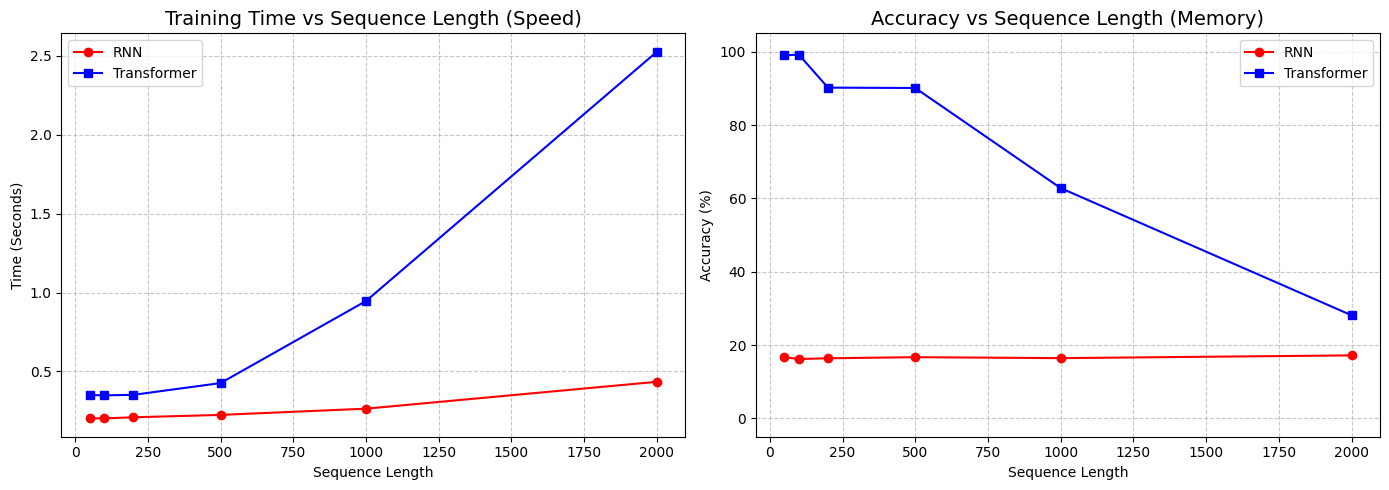

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sequence_lengths, rnn_mean_times, marker='o', label='RNN', color='red')
ax1.plot(sequence_lengths, tf_mean_times, marker='s', label='Transformer', color='blue')
ax1.set_title('Training Time vs Sequence Length (Speed)', fontsize=14)
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Time (Seconds)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 그래프 2: 정확도 비교 (장기 기억력 - 가설 2 검증)
ax2.plot(sequence_lengths, rnn_mean_accs, marker='o', label='RNN', color='red')
ax2.plot(sequence_lengths, tf_mean_accs, marker='s', label='Transformer', color='blue')
ax2.set_title('Accuracy vs Sequence Length (Memory)', fontsize=14)
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(-5, 105)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()